Error analysis

In [41]:
import pandas as pd
import ast
import numpy as np
from itertools import combinations
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
test_data = pd.read_csv("../data/test_data_with_predictions.csv")

# Convert prediction columns back to dict
pred_cols = [col for col in test_data.columns if col.startswith("pred_") and not col.endswith("_labels")]
for col in pred_cols:
    test_data[col] = test_data[col].apply(ast.literal_eval)

# Define emotion columns
emotion_cols = ['admiration', 'amusement', 'anger', 'annoyance', 'approval',
                'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
                'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
                'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism',
                'pride', 'realization', 'relief', 'remorse', 'sadness',
                'surprise', 'neutral']

# Prediction column to analyse
pred_col_name = "pred_roberta_minimal"

# Build binary prediction matrix
pred_binary = pd.DataFrame(0, index=test_data.index, columns=emotion_cols)
for idx, pred in enumerate(test_data[pred_col_name]):
    if isinstance(pred, dict):
        for emotion, val in pred.items():
            if emotion in emotion_cols and val == 1:
                pred_binary.loc[pred_binary.index[idx], emotion] = 1

Error Combinations
This shows how often which error combination occurs

In [42]:
# Analyze error combinations
combo_counts = Counter()

# Iterate through each row to count TP, FP, FN combinations
for i in range(len(test_data)):
    true_row = test_data[emotion_cols].iloc[i]
    pred_row = pred_binary.iloc[i]

    # Calculate number of True Positives, False Positives, and False Negatives for the current row
    tp = int(((pred_row == 1) & (true_row == 1)).sum())
    fp = int(((pred_row == 1) & (true_row == 0)).sum())
    fn = int(((pred_row == 0) & (true_row == 1)).sum())

    # Only relevant for rows with at least one error (FP or FN)
    if fp > 0 or fn > 0:
        parts = []
        # Error Combination is addrd to the counter
        if tp > 0: parts.append(f"{tp}TP")
        if fp > 0: parts.append(f"{fp}FP")
        if fn > 0: parts.append(f"{fn}FN")
        combo_counts["_".join(parts)] += 1

# Convert the combination counts to a DataFrame for better visualization
combo_df = pd.DataFrame(combo_counts.items(), columns=["Combination", "Count"])
combo_df = combo_df.sort_values("Count", ascending=False).reset_index(drop=True)

# Display the error combinations and their counts
print("=== Error Combinations ===")
print(combo_df.to_string(index=False))

=== Error Combinations ===
Combination  Count
    1TP_1FN    296
    1TP_2FN    126
    1TP_3FN     97
    1TP_4FN     43
        2FN     42
        3FN     40
        4FN     31
    1FP_2FN     24
    1FP_1FN     16
        5FN     15
    1FP_3FN     14
    1TP_5FN     14
        6FN     13
        1FN     12
    1FP_4FN      9
    1FP_5FN      7
    2TP_1FN      5
        7FN      4
1TP_1FP_2FN      2
    1TP_6FN      2
1TP_1FP_1FN      2
    1FP_6FN      2
    2TP_3FN      1
    1FP_8FN      1
    1TP_1FP      1
    2TP_4FN      1


Errors per Emotion

In [43]:
# Analyze errors per emotion
emotion_errors = []
for e in emotion_cols:
    true_col = test_data[e]
    pred_col = pred_binary[e]

    # Calculate TP, FP, FN, total true, total predicted, and error rates for the current emotion
    tp = int(((pred_col == 1) & (true_col == 1)).sum())
    fp = int(((pred_col == 1) & (true_col == 0)).sum())
    fn = int(((pred_col == 0) & (true_col == 1)).sum())
    total_true = int(true_col.sum())
    total_pred = int(pred_col.sum())
    errors = fp + fn
    error_rate = errors / (total_true + total_pred) if (total_true + total_pred) > 0 else 0

    emotion_errors.append({
        "emotion": e,
        "TP": tp, "FP": fp, "FN": fn,
        "Total True": total_true,
        "Total Predicted": total_pred,
        "Errors (abs)": errors,
        "Error Rate": f"{error_rate * 100:.1f}%"
    })

# Convert emotion error data to DataFrame and sort by absolute errors
emotion_error_df = pd.DataFrame(emotion_errors).set_index("emotion")
emotion_error_df = emotion_error_df.sort_values("Errors (abs)", ascending=False)

# Display errors per emotion
print("\n=== Errors per Emotion ===")
print(emotion_error_df.to_string())


=== Errors per Emotion ===
                 TP  FP   FN  Total True  Total Predicted  Errors (abs) Error Rate
emotion                                                                           
neutral         462  36  250         712              498           286      23.6%
approval         14   4  161         175               18           165      85.5%
annoyance        16   2  145         161               18           147      82.1%
disapproval      15   2  115         130               17           117      79.6%
anger            24   3  105         129               27           108      69.2%
realization       5   0   98         103                5            98      90.7%
disappointment   10   1   92         102               11            93      82.3%
curiosity        10   4   81          91               14            85      81.0%
excitement        5   1   82          87                6            83      89.2%
admiration       37   4   74         111               41  

Errors by number of true emotions

In [44]:
# Analyze errors by number of true emotions
true_counts = test_data[emotion_cols].sum(axis=1)

# Calculate TP, FP, FN, error rates and other metrics for each cardinality of true emotions
cardinality_analysis = []
for n in sorted(true_counts.unique()):
    mask = true_counts == n
    subset_true = test_data[emotion_cols][mask]
    subset_pred = pred_binary[mask]

    tp = int(((subset_pred == 1) & (subset_true == 1)).values.sum())
    fp = int(((subset_pred == 1) & (subset_true == 0)).values.sum())
    fn = int(((subset_pred == 0) & (subset_true == 1)).values.sum())
    n_sentences = int(mask.sum())

    cardinality_analysis.append({
        "True Emotion Count": int(n),
        "Sentences": n_sentences,
        "Total True Emotions":n * n_sentences,
        "TP": tp, 
        "TP (%)": f"{tp / (tp + fn) * 100:.1f}%" if (tp + fn) > 0 else "0%",
        "FP": fp, 
        "FP (%))": f"{fp / (fp + tp) * 100:.1f}%" if (fp + tp) > 0 else "0%",
        "FN": fn,
        "FN (%)": f"{fn / (fn + tp) * 100:.1f}%" if (fn + tp) > 0 else "0%",
        "Errors (abs)": fp + fn,
        "Error (%))": f"{(fp + fn) / (tp + fp + fn) * 100:.1f}%" if (tp + fp + fn) > 0 else "0%",
        "Errors per Sentence": f"{(fp + fn) / n_sentences:.2f}",
        })

# Convert cardinality analysis to DataFrame and display
cardinality_df = pd.DataFrame(cardinality_analysis).set_index("True Emotion Count")
print("\n=== Errors by Number of True Emotions ===")
print(cardinality_df.to_string())


=== Errors by Number of True Emotions ===
                    Sentences  Total True Emotions   TP TP (%)  FP FP (%))   FN  FN (%)  Errors (abs) Error (%)) Errors per Sentence
True Emotion Count                                                                                                                  
1                         205                  205  177  86.3%  17    8.8%   28   13.7%            45      20.3%                0.22
2                         368                  736  306  41.6%  26    7.8%  430   58.4%           456      59.8%                1.24
3                         187                  561  138  24.6%  16   10.4%  423   75.4%           439      76.1%                2.35
4                         137                  548   97  17.7%   9    8.5%  451   82.3%           460      82.6%                3.36
5                          66                  330   45  13.6%   7   13.5%  285   86.4%           292      86.6%                4.42
6                         

Errors by text length

In [45]:
# 
test_data_copy = test_data.copy()
test_data_copy["text_length"] = test_data_copy["text"].str.len()
test_data_copy["FP"] = ((pred_binary == 1) & (test_data[emotion_cols] == 0)).sum(axis=1)
test_data_copy["FN"] = ((pred_binary == 0) & (test_data[emotion_cols] == 1)).sum(axis=1)
test_data_copy["errors"] = test_data_copy["FP"] + test_data_copy["FN"]
test_data_copy["true_emotion_count"] = test_data[emotion_cols].sum(axis=1)
test_data_copy["pred_emotion_count"] = pred_binary.sum(axis=1)

bins = [0, 30, 60, 100, 150, 200, 99999]
labels = ["<30", "30-60", "60-100", "100-150", "150-200", ">200"]
test_data_copy["length_bin"] = pd.cut(test_data_copy["text_length"], bins=bins, labels=labels)

length_df = test_data_copy.groupby("length_bin", observed=True).agg(
    Sentences=("errors", "count"),
    Avg_True_Emotions=("true_emotion_count", "mean"),
    Avg_Pred_Emotions=("pred_emotion_count", "mean"),
    FP_total=("FP", "sum"),
    FN_total=("FN", "sum"),
    Errors_per_Sentence=("errors", "mean"),
    FP_per_Sentence=("FP", "mean"),
    FN_per_Sentence=("FN", "mean"),
).round(2)

print("\n=== Errors by Text Length ===")
print(length_df.to_string())


=== Errors by Text Length ===
            Sentences  Avg_True_Emotions  Avg_Pred_Emotions  FP_total  FN_total  Errors_per_Sentence  FP_per_Sentence  FN_per_Sentence
length_bin                                                                                                                            
<30               233               2.04               0.90        12       278                 1.24             0.05             1.19
30-60             286               2.61               0.87        20       518                 1.88             0.07             1.81
60-100            310               2.77               0.84        28       628                 2.12             0.09             2.03
100-150           161               3.13               0.82        18       390                 2.53             0.11             2.42
150-200            10               2.40               0.90         0        15                 1.50             0.00             1.50


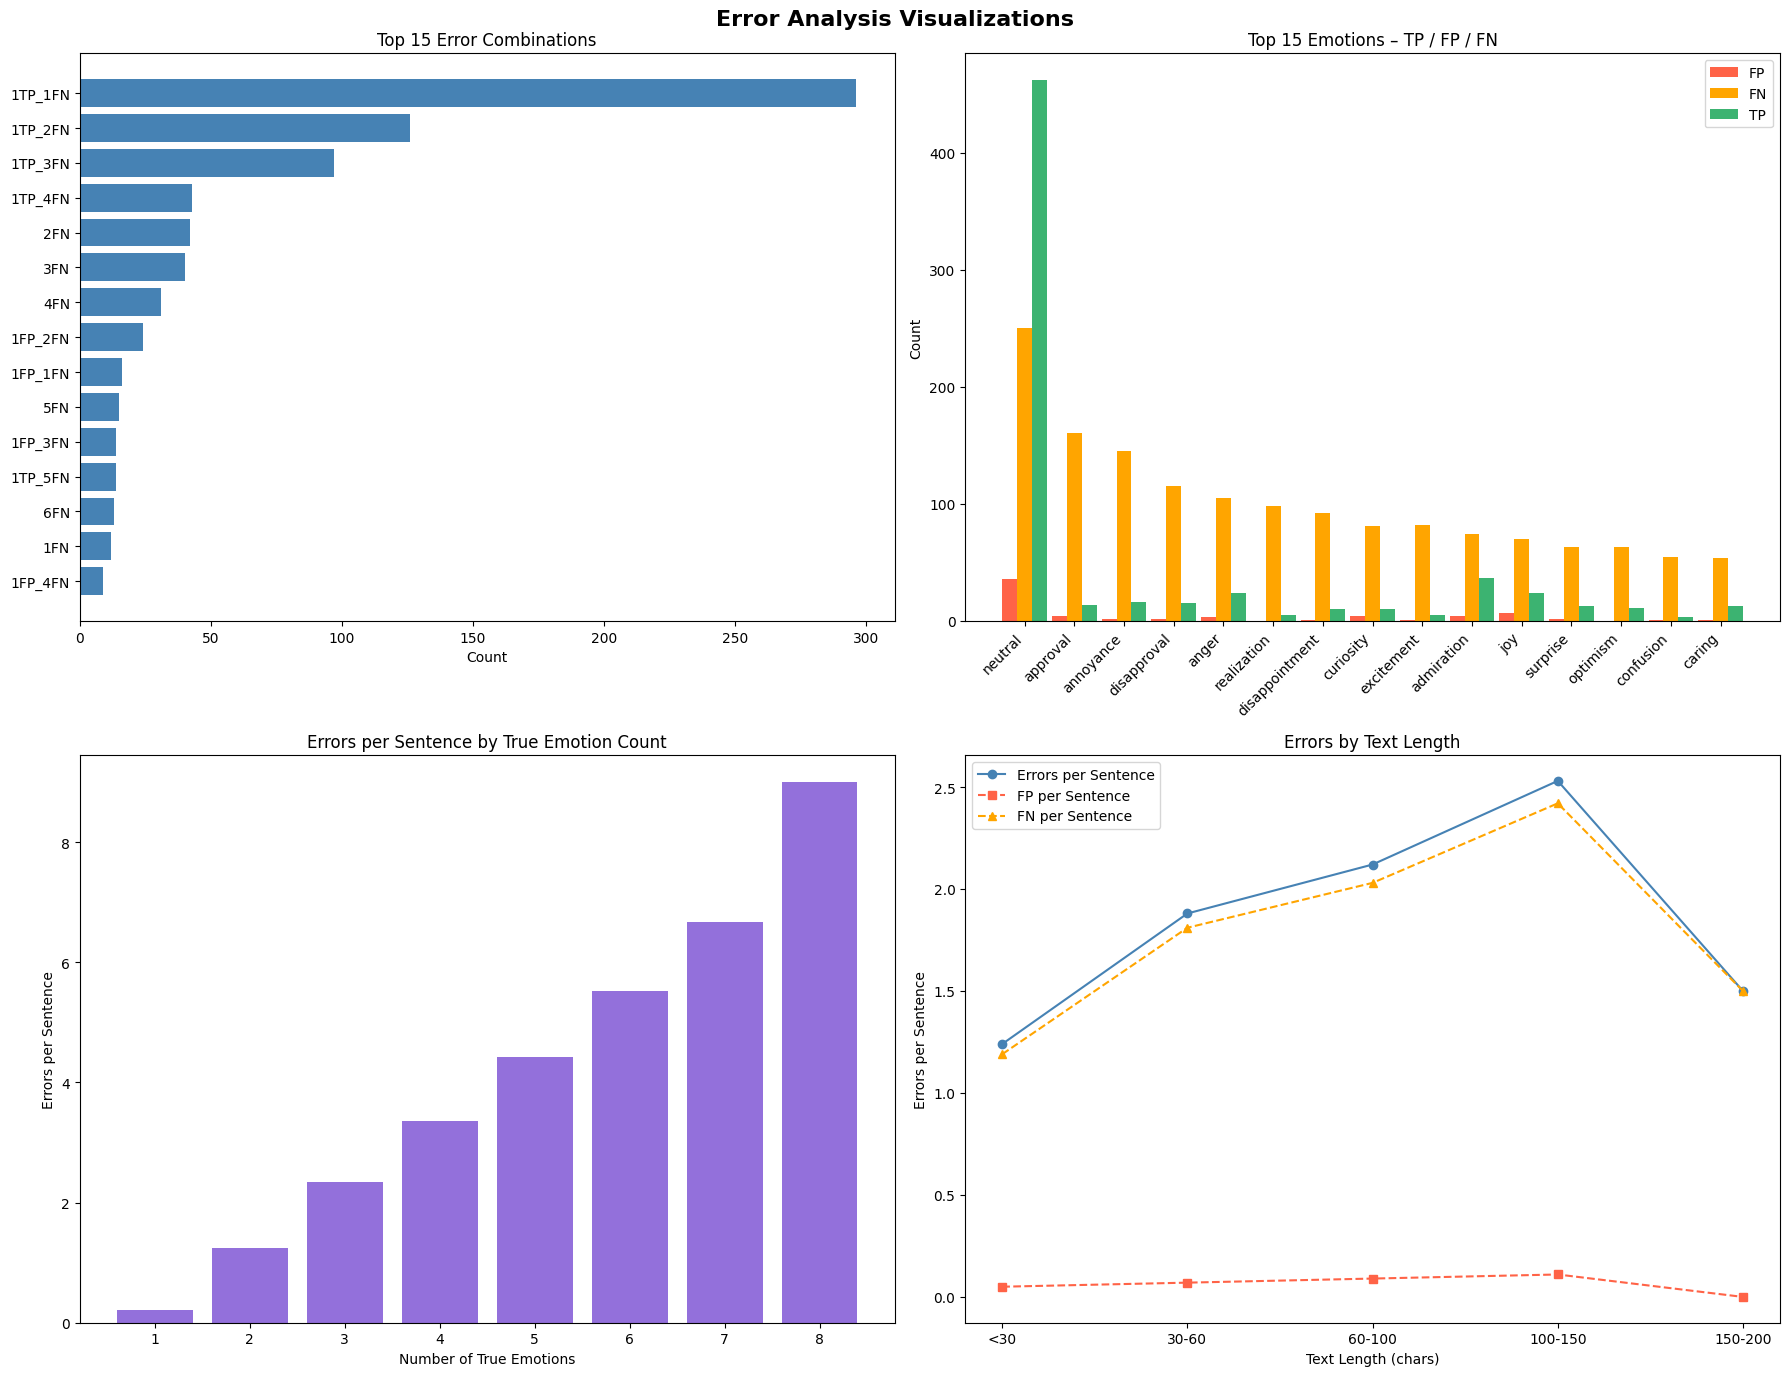

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Error Analysis Visualizations", fontsize=16, fontweight="bold")

# ── 1. ERROR COMBINATIONS ───────────────────────────────────────────────────
top_combos = combo_df.head(15)
axes[0, 0].barh(top_combos["Combination"], top_combos["Count"], color="steelblue")
axes[0, 0].set_title("Top 15 Error Combinations")
axes[0, 0].set_xlabel("Count")
axes[0, 0].invert_yaxis()

# ── 2. ERRORS PER EMOTION ───────────────────────────────────────────────────
top_emotions = emotion_error_df.head(15)
x = range(len(top_emotions))
width = 0.3
axes[0, 1].bar([i - width for i in x], top_emotions["FP"], width=width, label="FP", color="tomato")
axes[0, 1].bar([i for i in x], top_emotions["FN"], width=width, label="FN", color="orange")
axes[0, 1].bar([i + width for i in x], top_emotions["TP"], width=width, label="TP", color="mediumseagreen")
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(top_emotions.index, rotation=45, ha="right")
axes[0, 1].set_title("Top 15 Emotions – TP / FP / FN")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# ── 3. ERRORS BY NUMBER OF TRUE EMOTIONS ────────────────────────────────────
error_rates = cardinality_df["Errors per Sentence"].astype(float)
axes[1, 0].bar(error_rates.index.astype(str), error_rates.values, color="mediumpurple")
axes[1, 0].set_title("Errors per Sentence by True Emotion Count")
axes[1, 0].set_xlabel("Number of True Emotions")
axes[1, 0].set_ylabel("Errors per Sentence")

# ── 4. ERRORS BY TEXT LENGTH ────────────────────────────────────────────────
axes[1, 1].plot(length_df.index.astype(str), length_df["Errors_per_Sentence"], 
                marker="o", color="steelblue", label="Errors per Sentence")
axes[1, 1].plot(length_df.index.astype(str), length_df["FP_per_Sentence"], 
                marker="s", color="tomato", linestyle="--", label="FP per Sentence")
axes[1, 1].plot(length_df.index.astype(str), length_df["FN_per_Sentence"], 
                marker="^", color="orange", linestyle="--", label="FN per Sentence")
axes[1, 1].set_title("Errors by Text Length")
axes[1, 1].set_xlabel("Text Length (chars)")
axes[1, 1].set_ylabel("Errors per Sentence")
axes[1, 1].legend()

plt.tight_layout()
plt.show()
